# Grafico Smorzamento

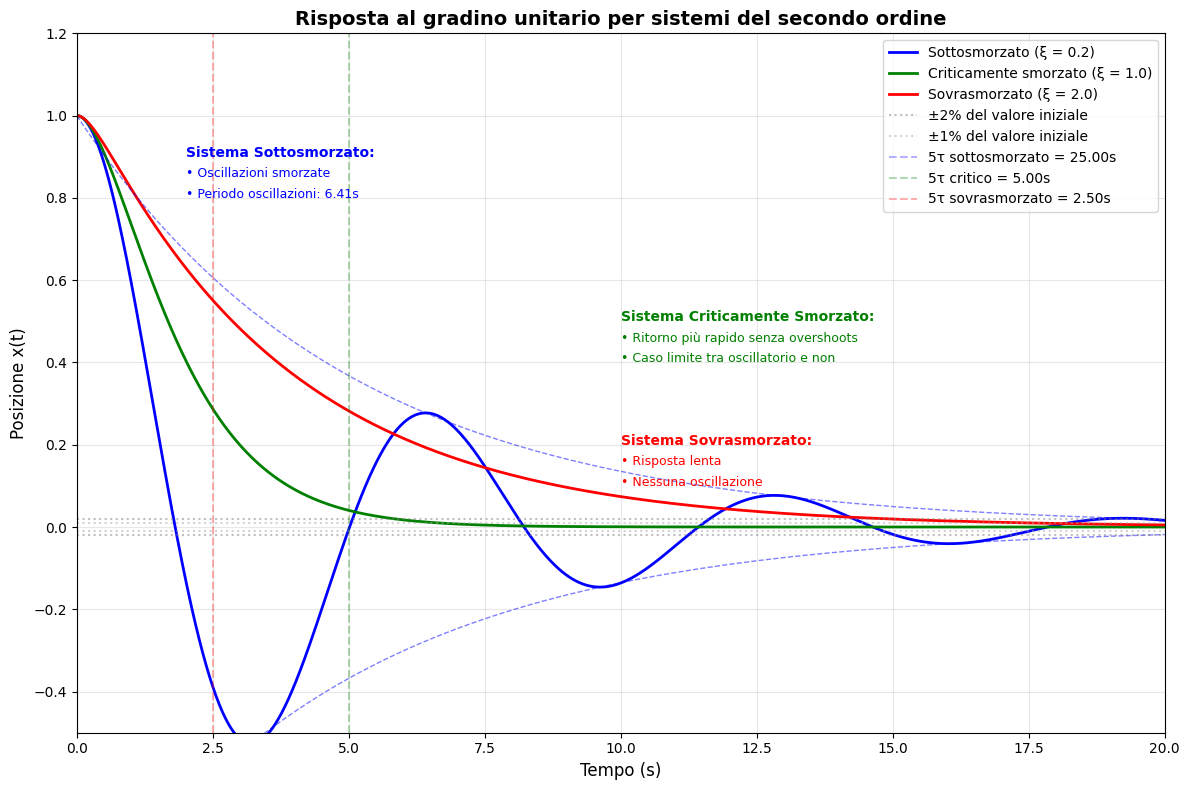

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Parametri del sistema
omega_n = 1.0  # Pulsazione naturale (rad/s)
t = np.linspace(0, 20, 1000)  # Vettore tempo

# Coefficienti di smorzamento
xi_under = 0.2    # Sottosmorzato
xi_critical = 1.0  # Criticalmente smorzato
xi_over = 2.0      # Sovrasmorzato

# Condizioni iniziali: x(0) = 1, x'(0) = 0
x0 = 1.0

# Sistema sottosmorzato (ξ < 1)
omega_d = omega_n * np.sqrt(1 - xi_under**2)  # Pulsazione smorzata
x_under = x0 * np.exp(-xi_under * omega_n * t) * (
    np.cos(omega_d * t) + (xi_under * omega_n / omega_d) * np.sin(omega_d * t)
)

# Sistema criticamente smorzato (ξ = 1)
x_critical = x0 * np.exp(-omega_n * t) * (1 + omega_n * t)

# Sistema sovrasmorzato (ξ > 1)
r1 = -omega_n * (xi_over - np.sqrt(xi_over**2 - 1))
r2 = -omega_n * (xi_over + np.sqrt(xi_over**2 - 1))
A = x0 * r2 / (r2 - r1)
B = -x0 * r1 / (r2 - r1)
x_over = A * np.exp(r1 * t) + B * np.exp(r2 * t)

# Calcolo delle costanti di tempo
tau_under = 1 / (xi_under * omega_n)
tau_critical = 1 / omega_n
tau_over = 1 / (xi_over * omega_n)

# Crea il grafico
plt.figure(figsize=(12, 8))

# Plot delle risposte
plt.plot(t, x_under, 'b-', linewidth=2, label=f'Sottosmorzato (ξ = {xi_under})')
plt.plot(t, x_critical, 'g-', linewidth=2, label=f'Criticamente smorzato (ξ = {xi_critical})')
plt.plot(t, x_over, 'r-', linewidth=2, label=f'Sovrasmorzato (ξ = {xi_over})')

# Aggiungi gli inviluppi esponenziali per il sistema sottosmorzato
envelope_upper = x0 * np.exp(-xi_under * omega_n * t)
envelope_lower = -x0 * np.exp(-xi_under * omega_n * t)
plt.plot(t, envelope_upper, 'b--', alpha=0.5, linewidth=1)
plt.plot(t, envelope_lower, 'b--', alpha=0.5, linewidth=1)

# Linee orizzontali per i livelli di assestamento
plt.axhline(y=0.02*x0, color='gray', linestyle=':', alpha=0.5, label='±2% del valore iniziale')
plt.axhline(y=-0.02*x0, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=0.01*x0, color='darkgray', linestyle=':', alpha=0.5, label='±1% del valore iniziale')
plt.axhline(y=-0.01*x0, color='darkgray', linestyle=':', alpha=0.5)

# Linee verticali per 5τ
plt.axvline(x=5*tau_under, color='blue', linestyle='--', alpha=0.3, label=f'5τ sottosmorzato = {5*tau_under:.2f}s')
plt.axvline(x=5*tau_critical, color='green', linestyle='--', alpha=0.3, label=f'5τ critico = {5*tau_critical:.2f}s')
plt.axvline(x=5*tau_over, color='red', linestyle='--', alpha=0.3, label=f'5τ sovrasmorzato = {5*tau_over:.2f}s')

# Formattazione del grafico
plt.grid(True, alpha=0.3)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Posizione x(t)', fontsize=12)
plt.title('Risposta al gradino unitario per sistemi del secondo ordine', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.xlim([0, 20])
plt.ylim([-0.5, 1.2])

# Aggiungi annotazioni
plt.text(2, 0.9, 'Sistema Sottosmorzato:', fontsize=10, fontweight='bold', color='blue')
plt.text(2, 0.85, '• Oscillazioni smorzate', fontsize=9, color='blue')
plt.text(2, 0.80, f'• Periodo oscillazioni: {2*np.pi/omega_d:.2f}s', fontsize=9, color='blue')

plt.text(10, 0.5, 'Sistema Criticamente Smorzato:', fontsize=10, fontweight='bold', color='green')
plt.text(10, 0.45, '• Ritorno più rapido senza overshoots', fontsize=9, color='green')
plt.text(10, 0.40, '• Caso limite tra oscillatorio e non', fontsize=9, color='green')

plt.text(10, 0.2, 'Sistema Sovrasmorzato:', fontsize=10, fontweight='bold', color='red')
plt.text(10, 0.15, '• Risposta lenta', fontsize=9, color='red')
plt.text(10, 0.10, '• Nessuna oscillazione', fontsize=9, color='red')

# Equalizza gli assi per una migliore visualizzazione
plt.tight_layout()

# Mostra il grafico
plt.show()